In [1]:
# 1. Importamos las librerías necesarias
import pandas as pd
import numpy as np

# Cargar el dataset original
df_original = pd.read_csv('Neo_Met_plants.csv')
Med_Plants = df_original.copy()

print("Dataset original cargado.")
print(f"Forma original: {Med_Plants.shape}")
# Librerías para dividir los datos y preprocesarlos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelo 2: Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

# Métricas para evaluar el modelo
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# 2. Cargamos el dataset y lo renombramos
# Asumimos que el archivo 'Neo_Met_plants.csv' está en la misma carpeta que este notebook.
df_original = pd.read_csv('Neo_Met_plants.csv')
# Renombramos el DataFrame a 'Med_Plants'
Med_Plants = df_original.copy()

# 3. Echemos un primer vistazo a los datos para confirmar que se cargaron bien

Med_Plants.head()

Dataset original cargado.
Forma original: (1341, 20)


,Entry_ID,IRMS_d13C_Collagen,d15N_Collagen,Latitude_N,Longitude_E,General_Category_or_Family,Sampled_Element,Cultural_Horizon,Species,Genus,Absolute_Chronology,Modern_Country,Mediterranean_Basin,Fecha_Min_BP_corr,Fecha_Max_BP_corr,Chronological_Period_corr,Chronological_Period_clean,Cereal,Cereal_Type,Pulse_Type
0,14,-25.4,1.6,44.413343,9.162563,Fabaceae,Seed,NaN,faba,Vicia,3500 - 3000 BCE ; 3000 - 2500 BCE ; 2500 - 200...,Italy,Western_Med,5450.0,4950.0,Chalcolithic,Chalcolithic,other,not_cereal,faba_bean
1,15,-25.9,1.5,44.413343,9.162563,Fabaceae,Seed,NaN,faba,Vicia,3500 - 3000 BCE ; 3000 - 2500 BCE ; 2500 - 200...,Italy,Western_Med,5450.0,4950.0,Chalcolithic,Chalcolithic,other,not_cereal,faba_bean
2,16,-26.0,1.0,44.413343,9.162563,Poaceae,Seed,NaN,vulgare,Hordeum,3500 - 3000 BCE ; 3000 - 2500 BCE ; 2500 - 200...,Italy,Western_Med,5450.0,4950.0,Chalcolithic,Chalcolithic,barley,barley,not_pulse
3,17,-26.0,1.3,44.413343,9.162563,Poaceae,Seed,NaN,vulgare,Hordeum,3500 - 3000 BCE ; 3000 - 2500 BCE ; 2500 - 200...,Italy,Western_Med,5450.0,4950.0,Chalcolithic,Chalcolithic,barley,barley,not_pulse
4,18,-24.8,2.3,44.413343,9.162563,Poaceae,Seed,NaN,NaN,Triticum/Hordeum,3500 - 3000 BCE ; 3000 - 2500 BCE ; 2500 - 200...,Italy,Western_Med,5450.0,4950.0,Chalcolithic,Chalcolithic,wheat,barley,not_pulse


In [2]:
Med_Plants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1341 entries, 0 to 1340
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Entry_ID                    1341 non-null   int64  
 1   IRMS_d13C_Collagen          1341 non-null   float64
 2   d15N_Collagen               1341 non-null   float64
 3   Latitude_N                  1341 non-null   float64
 4   Longitude_E                 1341 non-null   float64
 5   General_Category_or_Family  1341 non-null   object 
 6   Sampled_Element             1267 non-null   object 
 7   Cultural_Horizon            1064 non-null   object 
 8   Species                     1336 non-null   object 
 9   Genus                       1341 non-null   object 
 10  Absolute_Chronology         1254 non-null   object 
 11  Modern_Country              1341 non-null   object 
 12  Mediterranean_Basin         1341 non-null   object 
 13  Fecha_Min_BP_corr           1254 

In [3]:
Med_Plants.describe()

,Entry_ID,IRMS_d13C_Collagen,d15N_Collagen,Latitude_N,Longitude_E,Fecha_Min_BP_corr,Fecha_Max_BP_corr
count,1341.000000,1341.000000,1341.000000,1341.000000,1341.000000,1254.000000,1254.000000
mean,1457.438479,-22.931521,2.966756,39.242540,18.333868,4521.052632,4032.057416
std,940.531183,3.649638,2.723270,2.905841,11.564357,1809.895477,1798.746192
min,14.000000,-28.200000,-4.200000,29.240000,-9.440000,2550.000000,2350.000000
25%,558.000000,-24.110000,1.200000,37.062972,12.715642,2950.000000,2450.000000
50%,1630.000000,-23.500000,2.670000,40.418422,22.420611,3950.000000,3450.000000
75%,2409.000000,-22.700000,4.580000,41.885726,25.161653,5450.000000,4950.000000
max,2837.000000,0.640000,15.400000,44.413343,41.058576,9950.000000,9450.000000


In [4]:
# 1. Definir las variables predictoras (X) y la variable objetivo (y)
# # Filtrar solo las filas donde Cereal sea 'barley' o 'wheat'
df_wheat_barley = Med_Plants[Med_Plants['Cereal'].isin(['barley', 'wheat'])].copy()

print(f"Filas después del filtro (solo barley y wheat): {df_wheat_barley.shape[0]}")

# 2. Verificar cuántos hay de cada uno
print("\nConteo por tipo de cereal:")
print(df_wheat_barley['Cereal'].value_counts())

# 3. Crear la columna 'Cereal_encoded' (0 = barley, 1 = wheat)
df_wheat_barley['Cereal_encoded'] = (df_wheat_barley['Cereal'] == 'wheat').astype(int)

# Verificar que la codificación está correcta
print("\nVerificación de codificación (debería coincidir con el conteo anterior):")
print(df_wheat_barley[['Cereal', 'Cereal_encoded']].head(10))

Filas después del filtro (solo barley y wheat): 1147

Conteo por tipo de cereal:
Cereal
barley    586
wheat     561
Name: count, dtype: int64

Verificación de codificación (debería coincidir con el conteo anterior):
    Cereal  Cereal_encoded
2   barley               0
3   barley               0
4    wheat               1
5    wheat               1
6    wheat               1
7    wheat               1
8    wheat               1
9   barley               0
10  barley               0
11  barley               0


In [5]:
from sklearn.preprocessing import LabelEncoder

# 1. Codificar 'Chronological_Period_clean' como números (0, 1, 2, ...)
#    LabelEncoder asigna un número entero único a cada categoría.
le_periodo = LabelEncoder()
df_wheat_barley['Periodo_encoded'] = le_periodo.fit_transform(df_wheat_barley['Chronological_Period_clean'])

# 2. Codificar 'Mediterranean_Basin' como números
le_cuenca = LabelEncoder()
df_wheat_barley['Cuenca_encoded'] = le_cuenca.fit_transform(df_wheat_barley['Mediterranean_Basin'])

# 3. Verificar las nuevas columnas
print("Nuevas columnas creadas:")
print(f"  - Periodo_encoded (valores únicos: {df_wheat_barley['Periodo_encoded'].nunique()})")
print(f"  - Cuenca_encoded (valores únicos: {df_wheat_barley['Cuenca_encoded'].nunique()})")

# 4. Ver la correspondencia entre valores originales y códigos
print("\nCorrespondencia para Periodo_encoded:")
periodo_mapping = df_wheat_barley[['Chronological_Period_clean', 'Periodo_encoded']].drop_duplicates().sort_values('Periodo_encoded')
print(periodo_mapping.to_string(index=False))

print("\nCorrespondencia para Cuenca_encoded:")
cuenca_mapping = df_wheat_barley[['Mediterranean_Basin', 'Cuenca_encoded']].drop_duplicates().sort_values('Cuenca_encoded')
print(cuenca_mapping.to_string(index=False))

Nuevas columnas creadas:
  - Periodo_encoded (valores únicos: 8)
  - Cuenca_encoded (valores únicos: 3)

Correspondencia para Periodo_encoded:
Chronological_Period_clean  Periodo_encoded
              Chalcolithic                0
          Early_Bronze_Age                1
            Early_Iron_Age                2
             Late_Iron_Age                3
            Late_Neolithic                4
    Middle_Late_Bronze_Age                5
                 Neolithic                6
                     Other                7

Correspondencia para Cuenca_encoded:
Mediterranean_Basin  Cuenca_encoded
        Central_Med               0
        Eastern_Med               1
        Western_Med               2


In [6]:
# 1. Definir las columnas predictoras (ahora con las columnas que acabamos de crear)
feature_columns = [
    'IRMS_d13C_Collagen',
    'd15N_Collagen',
    'Latitude_N',
    'Longitude_E',
    'Periodo_encoded',      # ✓ Ahora sí existe
    'Cuenca_encoded'        # ✓ Ahora sí existe
]

# Verificar que todas las columnas existen
missing_cols = [col for col in feature_columns if col not in df_wheat_barley.columns]
if missing_cols:
    print(f"⚠️ ATENCIÓN: Estas columnas no existen: {missing_cols}")
else:
    print("✓ Todas las columnas predictoras están presentes.")

# 2. Definir X e y
X = df_wheat_barley[feature_columns]
y = df_wheat_barley['Cereal_encoded']

print(f"\nVariables predictoras (X): {X.shape}")
print(f"Variable objetivo (y): {y.shape}")
print(f"\nDistribución de clases en 'y':")
print(y.value_counts())

✓ Todas las columnas predictoras están presentes.

Variables predictoras (X): (1147, 6)
Variable objetivo (y): (1147,)

Distribución de clases en 'y':
Cereal_encoded
0    586
1    561
Name: count, dtype: int64


In [7]:
# Dividir los datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño prueba: {X_test.shape[0]} muestras")

Tamaño entrenamiento: 917 muestras
Tamaño prueba: 230 muestras


In [8]:
# Escalar las características 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Escalar los datos (opcional pero lo mantenemos por consistencia)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Definir los hiperparámetros a probar
param_grid = {
    'n_estimators': [50, 100, 200],          # número de árboles
    'max_depth': [5, 10, None],              # profundidad máxima
    'min_samples_split': [2, 5, 10],         # muestras mínimas para dividir
    'min_samples_leaf': [1, 2, 4]            # muestras mínimas en hoja
}

# 2. Configurar la búsqueda con validación cruzada (5 pliegues)
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,                    # validación cruzada de 5 pliegues
    scoring='accuracy',      # métrica a optimizar
    n_jobs=-1,               # usar todos los procesadores para ir más rápido
    verbose=1                # muestra el progreso
)

# 3. Ejecutar la búsqueda (esto puede tomar varios minutos)
print("🔍 Buscando mejores hiperparámetros...")
grid_search.fit(X_train_scaled, y_train)

# 4. Mostrar los mejores resultados
print("\n✅ Búsqueda completada")
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor exactitud (validación cruzada): {grid_search.best_score_:.4f}")

# 5. Evaluar el modelo optimizado en el conjunto de prueba
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
print(f"Exactitud en datos de prueba con modelo optimizado: {accuracy_score(y_test, y_pred_best):.4f}")

# Comparativa con el modelo original (sin optimizar)
print("\n--- COMPARATIVA ---")
print(f"Modelo original (n_estimators=100, por defecto): 72.6%")
print(f"Modelo optimizado: {accuracy_score(y_test, y_pred_best):.4f}")

🔍 Buscando mejores hiperparámetros...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

✅ Búsqueda completada
Mejores parámetros encontrados: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Mejor exactitud (validación cruzada): 0.7175
Exactitud en datos de prueba con modelo optimizado: 0.7435

--- COMPARATIVA ---
Modelo original (n_estimators=100, por defecto): 72.6%
Modelo optimizado: 0.7435


In [10]:
import joblib

# Guardar el modelo en un archivo
joblib.dump(best_rf, 'random_forest_optimizado.pkl')
print("✅ Modelo guardado como 'random_forest_optimizado.pkl'")

# Opcional: guardar también el scaler (para escalar nuevos datos igual)
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler guardado como 'scaler.pkl'")

# Cómo cargarlo después (cuando lo necesites):
# modelo_cargado = joblib.load('random_forest_optimizado.pkl')
# scaler_cargado = joblib.load('scaler.pkl')

✅ Modelo guardado como 'random_forest_optimizado.pkl'
✅ Scaler guardado como 'scaler.pkl'


In [17]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

# ============================================
# CARGAR EL DATASET FINAL (el que usaste para entrenar)
# ============================================
# Ajusta la ruta según dónde tengas el archivo
df = pd.read_csv('Neo_Met_plants.csv')  # o 'Neo_Met_plants.csv'

# ============================================
# RECREAR LOS LABELENCODERS
# ============================================

# LabelEncoder para periodo
le_periodo = LabelEncoder()
le_periodo.fit(df['Chronological_Period_clean'].astype(str))
print(f"✅ le_periodo creado. Clases: {le_periodo.classes_.tolist()}")

# LabelEncoder para cuenca
le_cuenca = LabelEncoder()
le_cuenca.fit(df['Mediterranean_Basin'].astype(str))
print(f"✅ le_cuenca creado. Clases: {le_cuenca.classes_.tolist()}")

# ============================================
# GUARDAR LOS LABELENCODERS
# ============================================
# Crear la carpeta models/ si no existe
import os
os.makedirs('models', exist_ok=True)

# Guardar
joblib.dump(le_periodo, 'models/le_periodo.pkl')
joblib.dump(le_cuenca, 'models/le_cuenca.pkl')

print("✅ Archivos guardados en 'models/le_periodo.pkl' y 'models/le_cuenca.pkl'")

✅ le_periodo creado. Clases: ['Chalcolithic', 'Early_Bronze_Age', 'Early_Iron_Age', 'Late_Iron_Age', 'Late_Neolithic', 'Middle_Late_Bronze_Age', 'Neolithic', 'Other']
✅ le_cuenca creado. Clases: ['Central_Med', 'Eastern_Med', 'Western_Med']
✅ Archivos guardados en 'models/le_periodo.pkl' y 'models/le_cuenca.pkl'


In [11]:
# Guardar el mejor modelo encontrado por GridSearch
best_rf = grid_search.best_estimator_

print("✅ Modelo optimizado guardado como 'best_rf'")
print(f"Parámetros: {grid_search.best_params_}")

✅ Modelo optimizado guardado como 'best_rf'
Parámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [12]:
# Crear y entrenar el modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# print("Modelo Random Forest entrenado correctamente.")

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# Evaluar, Predecir sobre el conjunto de prueba
y_pred = model.predict(X_test_scaled)

# Métricas de rendimiento
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy): {accuracy:.4f}")

print("\n--- Informe de clasificación ---")
print(classification_report(y_test, y_pred, target_names=['cebada (0)', 'trigo (1)']))

print("\n--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_pred))

# Comparar primeras predicciones
print("\n--- Comparación (primeros 10 casos de prueba) ---")
comparison = pd.DataFrame({
    'Real': y_test.values[:10],
    'Predicción': y_pred[:10],
    'Correcta?': y_test.values[:10] == y_pred[:10]
})
print(comparison)

Exactitud (Accuracy): 0.7261

--- Informe de clasificación ---
              precision    recall  f1-score   support

  cebada (0)       0.74      0.71      0.73       118
   trigo (1)       0.71      0.74      0.72       112

    accuracy                           0.73       230
   macro avg       0.73      0.73      0.73       230
weighted avg       0.73      0.73      0.73       230


--- Matriz de Confusión ---
[[84 34]
 [29 83]]

--- Comparación (primeros 10 casos de prueba) ---
   Real  Predicción  Correcta?
0     0           0       True
1     1           1       True
2     0           1      False
3     1           1       True
4     0           0       True
5     0           1      False
6     1           0      False
7     0           0       True
8     1           0      False
9     0           0       True


In [15]:
# Ver qué variables fueron más importantes para el modelo
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Característica': feature_columns,
    'Importancia': importances
}).sort_values('Importancia', ascending=False)

print("\n--- Importancia de las características ---")
print(feature_importance_df)

# Gráfico de importancias
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Característica'], feature_importance_df['Importancia'], color='teal')
plt.xlabel('Importancia')
plt.title('Importancia de variables - RandomForest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


--- Importancia de las características ---
       Característica  Importancia
1       d15N_Collagen     0.381597
0  IRMS_d13C_Collagen     0.329152
3         Longitude_E     0.117107
2          Latitude_N     0.090384
4     Periodo_encoded     0.063353
5      Cuenca_encoded     0.018406


NameError: name 'plt' is not defined

AUC (Área bajo la curva ROC): 0.8254
(AUC > 0.7 = buen discriminador, > 0.8 = muy bueno, > 0.9 = excelente)


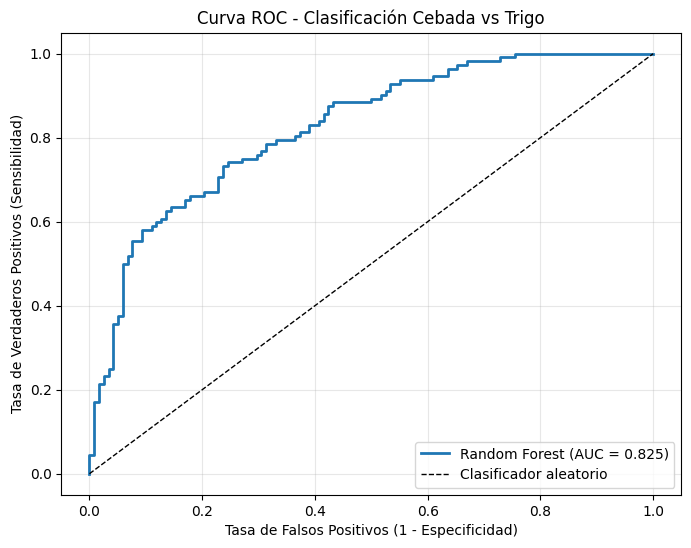

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predecir probabilidades (necesario para la curva ROC)
y_pred_proba = best_rf.predict_proba(X_test_scaled)[:, 1]

# Calcular AUC (Área bajo la curva)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC (Área bajo la curva ROC): {auc:.4f}")
print("(AUC > 0.7 = buen discriminador, > 0.8 = muy bueno, > 0.9 = excelente)")

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Graficar
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Clasificación Cebada vs Trigo')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Mostrar información general de las probabilidades
print("=" * 60)
print("ANÁLISIS DE PROBABILIDADES Y UMBRALES")
print("=" * 60)

# Probabilidades predichas para trigo (clase 1)
y_pred_proba = best_rf.predict_proba(X_test_scaled)[:, 1]

print(f"\n📊 Estadísticas de las probabilidades predichas:")
print(f"   Mínimo: {y_pred_proba.min():.4f}")
print(f"   Máximo: {y_pred_proba.max():.4f}")
print(f"   Media: {y_pred_proba.mean():.4f}")
print(f"   Mediana: {np.median(y_pred_proba):.4f}")

print(f"\n📌 Distribución por clase real:")
print(f"   Trigos reales (1): media de probabilidad = {y_pred_proba[y_test==1].mean():.4f}")
print(f"   Cebadas reales (0): media de probabilidad = {y_pred_proba[y_test==0].mean():.4f}")

# 2. Probar diferentes umbrales
print("\n" + "=" * 60)
print("AJUSTE DE UMBRAL - IMPACTO EN ACCURACY")
print("=" * 60)

umbrales = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
mejor_accuracy = 0
mejor_umbral = 0.5

for umbral in umbrales:
    y_pred_ajustado = (y_pred_proba >= umbral).astype(int)
    acc = accuracy_score(y_test, y_pred_ajustado)
    print(f"Umbral {umbral}: Accuracy = {acc:.4f}")
    if acc > mejor_accuracy:
        mejor_accuracy = acc
        mejor_umbral = umbral

print(f"\n✅ MEJOR UMBRAL ENCONTRADO: {mejor_umbral}")
print(f"✅ MEJOR ACCURACY CON ESE UMBRAL: {mejor_accuracy:.4f} ({mejor_accuracy*100:.1f}%)")
print(f"📊 Accuracy original (umbral 0.5): {accuracy_score(y_test, (y_pred_proba >= 0.5).astype(int)):.4f}")

if mejor_umbral != 0.5:
    print(f"\n🚀 MEJORA POSIBLE: Ajustando el umbral a {mejor_umbral} se gana {(mejor_accuracy - accuracy_score(y_test, (y_pred_proba >= 0.5).astype(int)))*100:.1f} puntos porcentuales")
else:
    print(f"\n✅ El umbral 0.5 ya es óptimo para este modelo.")

ANÁLISIS DE PROBABILIDADES Y UMBRALES

📊 Estadísticas de las probabilidades predichas:
   Mínimo: 0.0000
   Máximo: 0.9882
   Media: 0.4938
   Mediana: 0.4925

📌 Distribución por clase real:
   Trigos reales (1): media de probabilidad = 0.6558
   Cebadas reales (0): media de probabilidad = 0.3401

AJUSTE DE UMBRAL - IMPACTO EN ACCURACY
Umbral 0.3: Accuracy = 0.6870
Umbral 0.35: Accuracy = 0.6913
Umbral 0.4: Accuracy = 0.7174
Umbral 0.45: Accuracy = 0.7174
Umbral 0.5: Accuracy = 0.7435
Umbral 0.55: Accuracy = 0.7435
Umbral 0.6: Accuracy = 0.7391
Umbral 0.65: Accuracy = 0.7391
Umbral 0.7: Accuracy = 0.7174

✅ MEJOR UMBRAL ENCONTRADO: 0.5
✅ MEJOR ACCURACY CON ESE UMBRAL: 0.7435 (74.3%)
📊 Accuracy original (umbral 0.5): 0.7435

✅ El umbral 0.5 ya es óptimo para este modelo.


In [ ]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix

# Predicciones con mejor umbral
y_pred_mejor = (y_pred_proba >= mejor_umbral).astype(int)

print("=" * 60)
print("COMPARACIÓN DE MATRICES DE CONFUSIÓN")
print("=" * 60)

print("\n📊 CON UMBRAL 0.5 (original):")
print(confusion_matrix(y_test, (y_pred_proba >= 0.5).astype(int)))
print(f"Accuracy: {accuracy_score(y_test, (y_pred_proba >= 0.5).astype(int)):.4f}")

print(f"\n📊 CON MEJOR UMBRAL ({mejor_umbral}):")
print(confusion_matrix(y_test, y_pred_mejor))
print(f"Accuracy: {accuracy_score(y_test, y_pred_mejor):.4f}")

# Ver cuántos casos cambian
print(f"\n🔄 Casos que cambian de clase al ajustar el umbral: {(y_pred_mejor != (y_pred_proba >= 0.5).astype(int)).sum()} de {len(y_test)} muestras")

COMPARACIÓN DE MATRICES DE CONFUSIÓN

📊 CON UMBRAL 0.5 (original):
[[90 28]
 [31 81]]
Accuracy: 0.7435

📊 CON MEJOR UMBRAL (0.5):
[[90 28]
 [31 81]]
Accuracy: 0.7435

🔄 Casos que cambian de clase al ajustar el umbral: 0 de 230 muestras


In [ ]:
# Validación cruzada de 10 pliegues
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

print("=" * 60)
print("VALIDACIÓN CRUZADA (10 PLIEGUES) - MODELO OPTIMIZADO")
print("=" * 60)

# Configurar validación cruzada estratificada (mantiene proporción de clases)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Ejecutar validación cruzada
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print(f"\n📊 Exactitud por cada pliegue:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Pliegue {i:2d}: {score:.4f} ({score*100:.1f}%)")

print(f"\n📈 Estadísticas de la validación cruzada:")
print(f"   Media: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.1f}%)")
print(f"   Desviación estándar: {cv_scores.std():.4f}")
print(f"   Mínimo: {cv_scores.min():.4f} ({cv_scores.min()*100:.1f}%)")
print(f"   Máximo: {cv_scores.max():.4f} ({cv_scores.max()*100:.1f}%)")
print(f"   Rango: {cv_scores.max() - cv_scores.min():.4f}")

# Interpretación
print(f"\n✅ INTERPRETACIÓN:")
if cv_scores.std() < 0.02:
    print("   ✅ El modelo es MUY ESTABLE (baja variabilidad entre pliegues)")
elif cv_scores.std() < 0.04:
    print("   👍 El modelo es ESTABLE (variabilidad aceptable)")
else:
    print("   ⚠️ El modelo muestra variabilidad significativa")

print(f"\n📌 Comparativa:")
print(f"   Accuracy en test (modelo optimizado): 0.7435")
print(f"   Media validación cruzada: {cv_scores.mean():.4f}")
print(f"   Diferencia: {abs(0.7435 - cv_scores.mean()):.4f}")

VALIDACIÓN CRUZADA (10 PLIEGUES) - MODELO OPTIMIZADO

📊 Exactitud por cada pliegue:
   Pliegue  1: 0.7283 (72.8%)
   Pliegue  2: 0.7717 (77.2%)
   Pliegue  3: 0.7500 (75.0%)
   Pliegue  4: 0.6522 (65.2%)
   Pliegue  5: 0.6957 (69.6%)
   Pliegue  6: 0.6957 (69.6%)
   Pliegue  7: 0.7065 (70.7%)
   Pliegue  8: 0.7253 (72.5%)
   Pliegue  9: 0.7143 (71.4%)
   Pliegue 10: 0.7802 (78.0%)

📈 Estadísticas de la validación cruzada:
   Media: 0.7220 (72.2%)
   Desviación estándar: 0.0364
   Mínimo: 0.6522 (65.2%)
   Máximo: 0.7802 (78.0%)
   Rango: 0.1280

✅ INTERPRETACIÓN:
   👍 El modelo es ESTABLE (variabilidad aceptable)

📌 Comparativa:
   Accuracy en test (modelo optimizado): 0.7435
   Media validación cruzada: 0.7220
   Diferencia: 0.0215


In [ ]:
# Crear un DataFrame con los resultados de prueba
resultados_test = X_test.copy()
resultados_test['Cereal_real'] = y_test.values
resultados_test['Cereal_predicho'] = best_rf.predict(X_test_scaled)
resultados_test['Probabilidad_trigo'] = y_pred_proba
resultados_test['Acierto'] = resultados_test['Cereal_real'] == resultados_test['Cereal_predicho']

# Mostrar estadísticas de errores
print("=" * 60)
print("ANÁLISIS DE ERRORES DEL MODELO")
print("=" * 60)

total_muestras = len(resultados_test)
aciertos = resultados_test['Acierto'].sum()
errores = total_muestras - aciertos

print(f"\n📊 Resumen:")
print(f"   Total muestras en test: {total_muestras}")
print(f"   Aciertos: {aciertos} ({aciertos/total_muestras*100:.1f}%)")
print(f"   Errores: {errores} ({errores/total_muestras*100:.1f}%)")

print(f"\n📌 Tipos de error:")
# Errores: Cebada (0) predicha como Trigo (1) = Falsos Positivos
fp = ((resultados_test['Cereal_real'] == 0) & (resultados_test['Cereal_predicho'] == 1)).sum()
# Errores: Trigo (1) predicho como Cebada (0) = Falsos Negativos
fn = ((resultados_test['Cereal_real'] == 1) & (resultados_test['Cereal_predicho'] == 0)).sum()

print(f"   Cebada clasificada como Trigo (Falso Positivo): {fp}")
print(f"   Trigo clasificado como Cebada (Falso Negativo): {fn}")

# Mostrar ejemplos de errores
print("\n" + "=" * 60)
print("EJEMPLOS DE ERRORES (primeros 10 casos fallados)")
print("=" * 60)

errores_df = resultados_test[~resultados_test['Acierto']].copy()
if len(errores_df) > 0:
    # Seleccionar columnas relevantes para mostrar
    columnas_mostrar = [col for col in feature_columns if col in errores_df.columns]
    columnas_mostrar.extend(['Cereal_real', 'Cereal_predicho', 'Probabilidad_trigo'])
    
    print(errores_df[columnas_mostrar].head(10).to_string(index=False))
else:
    print("   ¡No hay errores! (esto sería sorprendente)")

# Análisis de las probabilidades en errores
print("\n" + "=" * 60)
print("ANÁLISIS DE PROBABILIDADES EN ERRORES")
print("=" * 60)

if len(errores_df) > 0:
    prob_errores = errores_df['Probabilidad_trigo']
    print(f"   Probabilidad media en errores: {prob_errores.mean():.4f}")
    print(f"   Probabilidad mínima en errores: {prob_errores.min():.4f}")
    print(f"   Probabilidad máxima en errores: {prob_errores.max():.4f}")
    print(f"\n   Interpretación: Los errores ocurren cuando el modelo tiene menos certeza")
    print(f"   (probabilidades cercanas al umbral 0.5)")
else:
    print("   No hay errores para analizar")

ANÁLISIS DE ERRORES DEL MODELO

📊 Resumen:
   Total muestras en test: 230
   Aciertos: 171 (74.3%)
   Errores: 59 (25.7%)

📌 Tipos de error:
   Cebada clasificada como Trigo (Falso Positivo): 28
   Trigo clasificado como Cebada (Falso Negativo): 31

EJEMPLOS DE ERRORES (primeros 10 casos fallados)
 IRMS_d13C_Collagen  d15N_Collagen  Latitude_N  Longitude_E  Periodo_encoded  Cuenca_encoded  Cereal_real  Cereal_predicho  Probabilidad_trigo
             -22.70           0.20   41.885726    12.715642                3               0            1                0            0.339758
             -23.20           0.60   41.885726    12.715642                3               0            1                0            0.468894
             -25.99           1.80   38.658203    23.189537                4               1            1                0            0.291858
             -23.90           1.40   41.885726    12.715642                3               0            1                0       

In [ ]:
print("=" * 60)
print("ERRORES MÁS CERCANOS AL UMBRAL (más dudosos)")
print("=" * 60)

# Errores con probabilidad entre 0.4 y 0.6 (zona de incertidumbre)
errores_dudosos = errores_df[(errores_df['Probabilidad_trigo'] >= 0.4) & (errores_df['Probabilidad_trigo'] <= 0.6)]
print(f"Errores en zona de incertidumbre (0.4-0.6): {len(errores_dudosos)} de {len(errores_df)} ({len(errores_dudosos)/len(errores_df)*100:.1f}%)")

print("\nEstos son los errores más comprensibles (cerca del 50% de probabilidad):")
print(errores_dudosos[feature_columns + ['Probabilidad_trigo', 'Cereal_real']].head(5).to_string(index=False))

print("\n" + "=" * 60)
print("ERRORES CON ALTA CONFIANZA (más preocupantes)")
print("=" * 60)

# Errores con probabilidad muy alta (>0.8) o muy baja (<0.2)
errores_confiados = errores_df[(errores_df['Probabilidad_trigo'] >= 0.8) | (errores_df['Probabilidad_trigo'] <= 0.2)]
print(f"Errores con alta confianza (<0.2 o >0.8): {len(errores_confiados)} de {len(errores_df)} ({len(errores_confiados)/len(errores_df)*100:.1f}%)")

if len(errores_confiados) > 0:
    print("\n⚠️ Estos errores son más preocupantes porque el modelo estaba muy seguro pero falló:")
    print(errores_confiados[feature_columns + ['Probabilidad_trigo', 'Cereal_real']].head(5).to_string(index=False))
else:
    print("✅ No hay errores con alta confianza. ¡Muy buen signo!")

ERRORES MÁS CERCANOS AL UMBRAL (más dudosos)
Errores en zona de incertidumbre (0.4-0.6): 29 de 59 (49.2%)

Estos son los errores más comprensibles (cerca del 50% de probabilidad):
 IRMS_d13C_Collagen  d15N_Collagen  Latitude_N  Longitude_E  Periodo_encoded  Cuenca_encoded  Probabilidad_trigo  Cereal_real
             -23.20           0.60   41.885726    12.715642                3               0            0.468894            1
             -23.90           1.40   41.885726    12.715642                3               0            0.498344            1
               0.64           0.08   35.298480    25.159555                2               1            0.522067            0
             -22.86           6.10   36.240491    36.382199                5               1            0.409095            1
             -24.00           1.80   41.885726    12.715642                3               0            0.411594            1

ERRORES CON ALTA CONFIANZA (más preocupantes)
Errores con alta 